In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [3]:
#parameters
H1 = 10000     #total population of cluster
H2 = 10000
a1 = 1.8   #exposure rate
a2 = 1.4     #represents cluster sanitation differences
sigma = 0.25   #symptomatic proportion
r = 0.2        #recovery rate
K = 1e6      #water saturation constant
ea = 1       #shedding rate asymptomatic
es = 37        #shedding rate symptomatic
mb = 0.6     #bacterial decay
m = 0.09  #mixing between clusters , cluster 2 --> 1

#interventions
chlorine_levels = {
    'Baseline (cl = 0 )' : 0.0,
    'Low (cl = 0.1)': 0.1,
    'Moderate (cl = 0.2 )': 0.2,
    'High (cl = 0.5)': 0.5
}
latrine_levels = {
    'Baseline (lc = 0 )' : 0.0,
    'Low (lc = 0.1)': 0.1,
    'Moderate (lc = 0.2 )': 0.2,
    'High (lc = 0.5)': 0.5
}
suspension_levels = {
    'Baseline (m = 0.09 )' : 0.09,
    'Partial (m = 0.03)': 0.03,
    'Most (m = 0.002 )': 0.002,
    'Full (m = 0)': 0.0
}
vax_levels = {
    'Baseline (0%)' : 0.0,
    'Low (25%)': 0.25,
    'Moderate (50%)': 0.5,
    'High (75%)': 0.75
}


#calculate R0
weighted_shedding = (1-sigma)*ea + sigma*es
R0_1 = (a1 * H1 * weighted_shedding) / (r * (mb ) * K)
R0_2 = (a2 * H2 * weighted_shedding) / (r * (mb ) * K)

#initial condiitons cluster 1
S1_0 = H1-1
Ia1_0 = 0
Is1_0 = 1
R1_0 = 0
B1_0 = 0
#initial condiitons cluster 2
S2_0 = H2
Ia2_0 = 0
Is2_0 = 0
R2_0 = 0
B2_0 = 0
#all initial conditions into y vector
y0 = [S1_0, Ia1_0, Is1_0, R1_0, B1_0, S2_0, Ia2_0, Is2_0, R2_0, B2_0]

#force of infection
def lambda_cluster1(B1, B2, Ia1,Ia2, Is1, Is2):
  water_local= ((B1/(K+B1))if B1>0 else 0 )
  return water_local

def lambda_cluster2(B1, B2, Ia1,Ia2, Is1, Is2):
  water_local= ((B2/(K+B2)) if B2>0 else 0 )
  water_other = m * (B1/(K+B1) if B1>0 else 0 )
  return water_local + water_other

#ode system
def cholera2_cluster (y,t):
  #all state variables
  S1, Ia1, Is1, R1, B1, S2, Ia2, Is2, R2, B2 = y
  #calculate force of infection for cluster 1 and 2
  lam1 = lambda_cluster1(B1, B2, Ia1,Ia2, Is1, Is2)
  lam2 = lambda_cluster2(B1, B2, Ia1,Ia2, Is1, Is2)
  #cluster 1 equations
  dS1= -a1 * lam1 * S1
  dIa1 = (1-sigma) * a1 * lam1 * S1 - r * Ia1
  dIs1 = sigma * a1 *  lam1 * S1 - r * Is1
  dR1 = r * (Ia1 + Is1)
  dB1 = -mb*B1 + ea*Ia1 + es*Is1
  #cluster 2 equations
  dS2= -a2 * lam2 * S2
  dIa2 = (1-sigma) * a2 * lam2 * S2 - r * Ia2
  dIs2 = sigma * a2 *  lam2 * S2 - r * Is2
  dR2 = r * (Ia2 + Is2)
  dB2 = -mb*B2 + ea*Ia2 + es*Is2
  #return all values
  return[dS1, dIa1, dIs1, dR1, dB1, dS2, dIa2, dIs2, dR2, dB2]


  #SOLVE MODEL######################
#time vector
t = np.linspace(0,365,1000) # 1 year
#solve ODEs
solution = odeint(cholera2_cluster, y0, t)
#extract solutions --> 10 column matrix
S1  = solution[:, 0]
Ia1 = solution[:, 1]
Is1 = solution[:, 2]
R1  = solution[:, 3]
B1  = solution[:, 4]

S2  = solution[:, 5]
Ia2 = solution[:, 6]
Is2 = solution[:, 7]
R2  = solution[:, 8]
B2  = solution[:, 9]
# Save baseline copies so interventions don't overwrite them
B1_baseline = B1.copy()
B2_baseline = B2.copy()
I1_baseline = (Ia1 + Is1).copy()
I2_baseline = (Ia2 + Is2).copy()




In [4]:
#unit tests
#mass conservation
total_pop1 = S1 + Ia1 + Is1 + R1
print("------------------------------------------------")
print("Cluster 1 Max deviation:", np.max(np.abs(total_pop1 - H1)))
if np.allclose(total_pop1, H1):
  print("Cluster 1 Mass conservation passed")
else:
  print("Cluster 1 Mass conservation failed")
print("------------------------------------------------")
total_pop2 = S2 + Ia2 + Is2 + R2
print("Cluster 2 Max deviation:", np.max(np.abs(total_pop2 - H2)))
if np.allclose(total_pop2, H2):
  print("Cluster 2 Mass conservation passed")
else:
  print("Cluster 2 Mass conservation failed")
print("------------------------------------------------")

#non-negativity
if np.all(S1 >= -1e-8) and np.all(Ia1 >= -1e-8) and np.all(R1>= -1e-8) and np.all(B1 >= -1e-8):
  print("Cluster 1 Non-negativity passed")
  print("------------------------------------------------")
else:
  print("Cluster 1 Non-negativity failed")
  print("------------------------------------------------")

#non-negativity
if np.all(S2 >= -1e-8) and np.all(Ia2 >= -1e-8) and np.all(R2>= -1e-8) and np.all(B2 >= -1e-8):
  print("Cluster 2 Non-negativity passed")
  print("------------------------------------------------")
else:
  print("Cluster 2 Non-negativity failed")
  print("------------------------------------------------")

------------------------------------------------
Cluster 1 Max deviation: 1.0913936421275139e-11
Cluster 1 Mass conservation passed
------------------------------------------------
Cluster 2 Max deviation: 1.0913936421275139e-11
Cluster 2 Mass conservation passed
------------------------------------------------
Cluster 1 Non-negativity passed
------------------------------------------------
Cluster 2 Non-negativity passed
------------------------------------------------


In [5]:
#total infections per cluster
I1_total = Ia1 + Is1
I2_total = Ia2 + Is2

#attack rate per cluster
attack_rate1 = (H1-S1[-1])/H1 * 100
attack_rate2 = (H2-S2[-1])/H2 * 100

#peak infections for clusters
peak1 = np.max(I1_total)
peakIa1 = np.max(Ia1)
peakIs1 = np.max(Is1)

peak1_time = t[np.argmax(I1_total)]
peakIa2 = np.max(Ia2)
peakIs2 = np.max(Is2)
peak2 = np.max(I2_total)
peak2_time = t[np.argmax(I2_total)]

#peak bacteria
peak_B1 = np.argmax(B1)
peak_B1_time = t[peak_B1]    # time in days
peak_B1_conc = B1[peak_B1]  # peak concentration

peak_B2 = np.argmax(B2)
peak_B2_time = t[peak_B2]    # time in days
peak_B2_conc = B2[peak_B2]  # peak concentration

#Cluster outbreak duration
epidemic_end1 = 2
epidemic_end2 = 1

active1 = np.where(I1_total > epidemic_end1)[0]
t1 = t[active1[0]]
t2 = t[active1[-1]]
cluster1_duration = t2 - t1

active2 = np.where(I2_total > epidemic_end2)[0]
t_A = t[active2[0]]
t_B = t[active2[-1]]
cluster2_duration = t_B - t_A


print("--Cluster 1 ------------------------")
print(f"Attack Rate {attack_rate1:.2f}%")
print(f"Cluster 1 outbreak length is {cluster1_duration:.0f} days")
print(f"Peak Infections:{peak1:.0f} ({100*peak1/H1:.1f}%)")
print(f"Peak Symptomatic: {peakIs1:.0f} ({100*peakIs1/peak1:.1f}%), Peak Asymptomatic:{peakIa1:.0f} ({100*peakIa1/peak1:.1f}%)")
print(f"Peak time: {peak1_time:.1f} days")
print(f"Peak bacterial concentration: {peak_B1_conc:.2f} cells/mL  at: {peak_B1_time:.1f} days")
print("----------------------------------------------")

print("--Cluster 2 ------------------------")
print(f"Attack Rate {attack_rate2:.2f}%")
print(f"Cluster 2 outbreak length is {cluster2_duration:.0f} days")
print(f"Peak Infections {peak2:.0f} ({100*peak2/H2:.1f}%)")
print(f"Peak Symptomatic: {peakIs2:.0f} ({100*peakIs2/peak2:.1f}%), Peak Asymptomatic:{peakIa2:.0f} ({100*peakIa2/peak2:.1f}%)")
print(f"Peak time: {peak2_time:.1f} days")
print(f"Peak bacterial concentration: {peak_B2_conc:.2f} cells/mL  at: {peak_B2_time:.1f} days")
print("----------------------------------------------")

print("--Spatial Heterogeniety-----------------------")
print(f"Difference in attack rates: {attack_rate1 - attack_rate2:.2f}%")
print(f"Delay of days in peak infection (Cluster 2 vs 1): {peak2_time - peak1_time:.1f} days")
print(f"Delay of days in peak bacterial conc. (Cluster 2 vs 1): {peak_B2_time - peak_B1_time:.1f} days")
print(f"Difference in outbreak duration: {cluster2_duration - cluster1_duration:.1f} days")
print("----------------------------------------------")

print(f"\nR₀ Calculation:")
print(f"Asymptomatic shedding rate: {1-sigma*ea}")
print(f"Symptomatic shedding rate: {sigma*es}")
print(f"Weighted shedding: {weighted_shedding}")
print(f"--Cluster 1 R₀: {R0_1:.2f}------")
if 2 <= R0_1 <= 4:
    print("R₀ in realistic range for cholera")
elif R0_1 < 2:
    print("R₀ below typical cholera range (2-4)")
elif R0_1> 5:
    print("R₀ above typical cholera range (2-4)")

print(f"--Cluster 2 R₀: {R0_2:.2f}------")
if 2 <= R0_2 <= 4:
    print("R₀ in realistic range for cholera")
elif R0_2 < 2:
    print("R₀ below typical cholera range (2-4)")
elif R0_2> 5:
    print("R₀ above typical cholera range (2-4)")
print("----------------------------------------------")

--Cluster 1 ------------------------
Attack Rate 57.83%
Cluster 1 outbreak length is 205 days
Peak Infections:465 (4.7%)
Peak Symptomatic: 116 (25.0%), Peak Asymptomatic:349 (75.0%)
Peak time: 96.1 days
Peak bacterial concentration: 7735.77 cells/mL  at: 97.9 days
----------------------------------------------
--Cluster 2 ------------------------
Attack Rate 42.71%
Cluster 2 outbreak length is 235 days
Peak Infections 306 (3.1%)
Peak Symptomatic: 77 (25.0%), Peak Asymptomatic:230 (75.0%)
Peak time: 110.7 days
Peak bacterial concentration: 5091.00 cells/mL  at: 112.2 days
----------------------------------------------
--Spatial Heterogeniety-----------------------
Difference in attack rates: 15.13%
Delay of days in peak infection (Cluster 2 vs 1): 14.6 days
Delay of days in peak bacterial conc. (Cluster 2 vs 1): 14.2 days
Difference in outbreak duration: 29.2 days
----------------------------------------------

R₀ Calculation:
Asymptomatic shedding rate: 0.75
Symptomatic shedding rate: 

In [6]:
print("Max I1_total:", np.max(I1_total))
print("epidemic_end threshold:", epidemic_end1)
print("active1 length:", len(active1))

Max I1_total: 465.47763946809283
epidemic_end threshold: 2
active1 length: 563


In [7]:
print(f"Max B1_baseline: {np.max(B1_baseline):.4f}")
print(f"Max B1_baseline * K: {np.max(B1_baseline) * K:.2f}")
print(f"K = {K}")
print('---' * 20)
print(f"Max B2_baseline: {np.max(B2_baseline):.4f}")
print(f"Max B2_baseline * K: {np.max(B2_baseline) * K:.2f}")
print(f"K = {K}")


Max B1_baseline: 7735.7680
Max B1_baseline * K: 7735767992.98
K = 1000000.0
------------------------------------------------------------
Max B2_baseline: 5091.0021
Max B2_baseline * K: 5091002141.06
K = 1000000.0


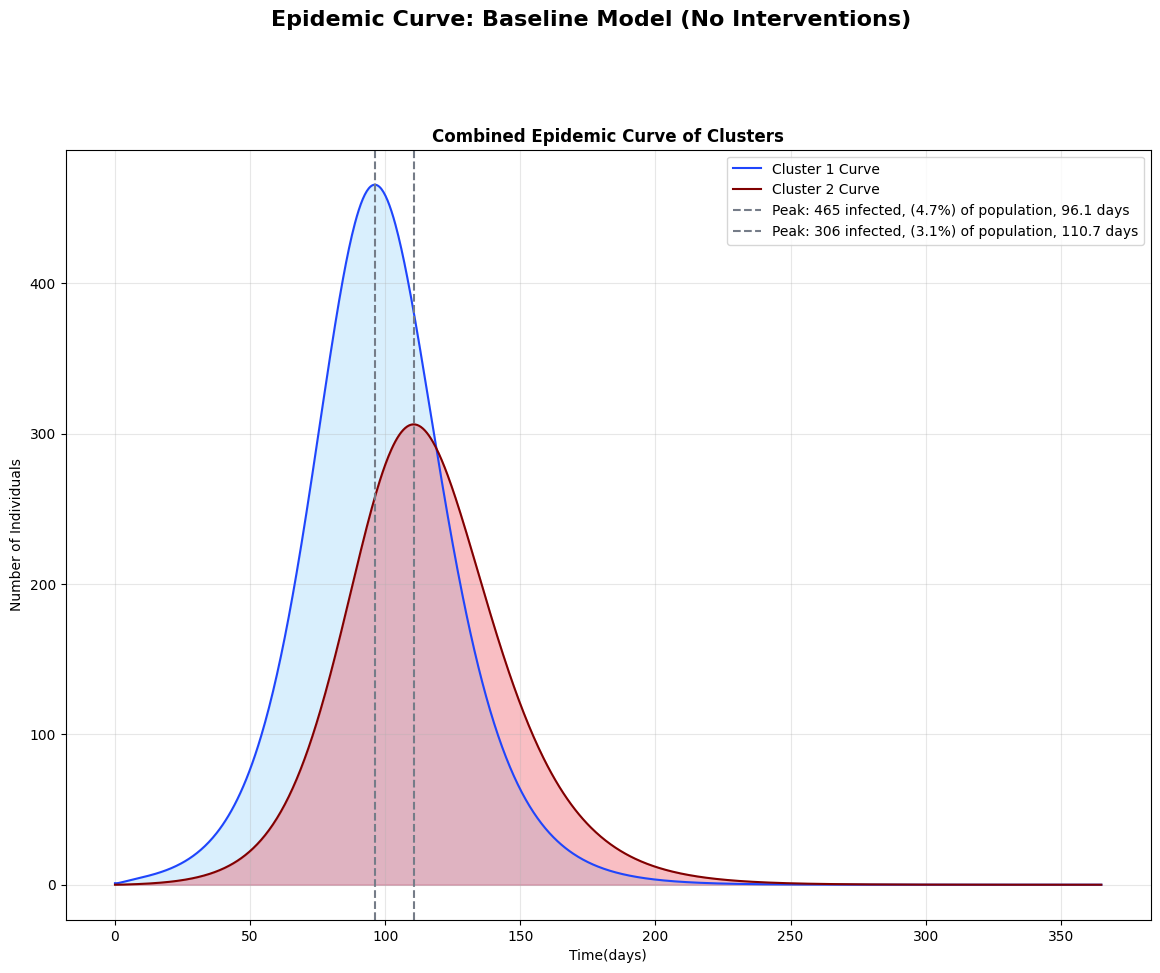

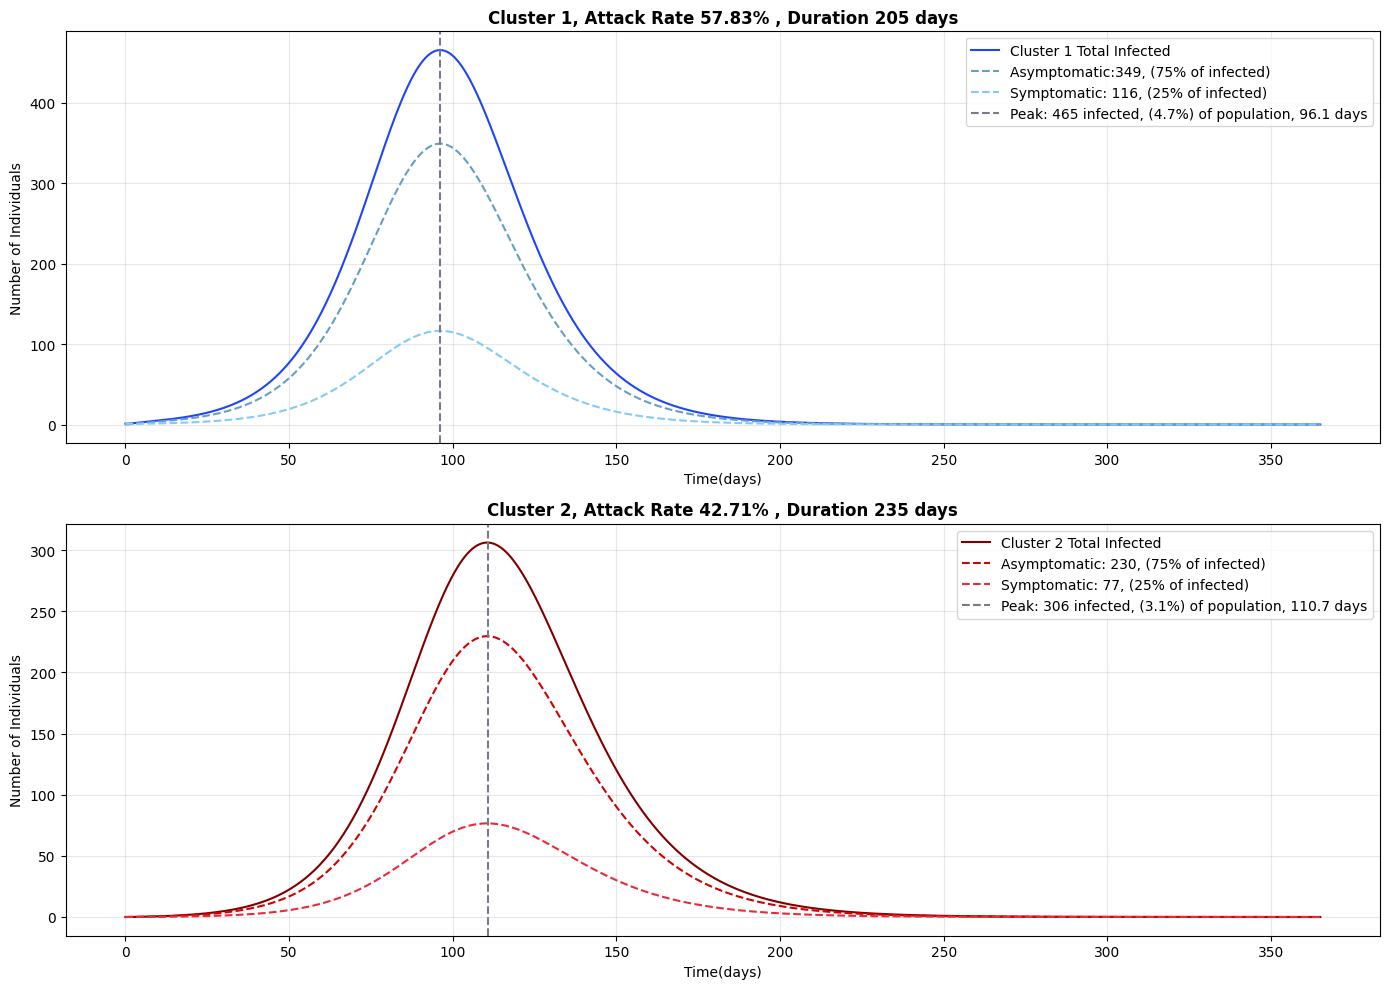

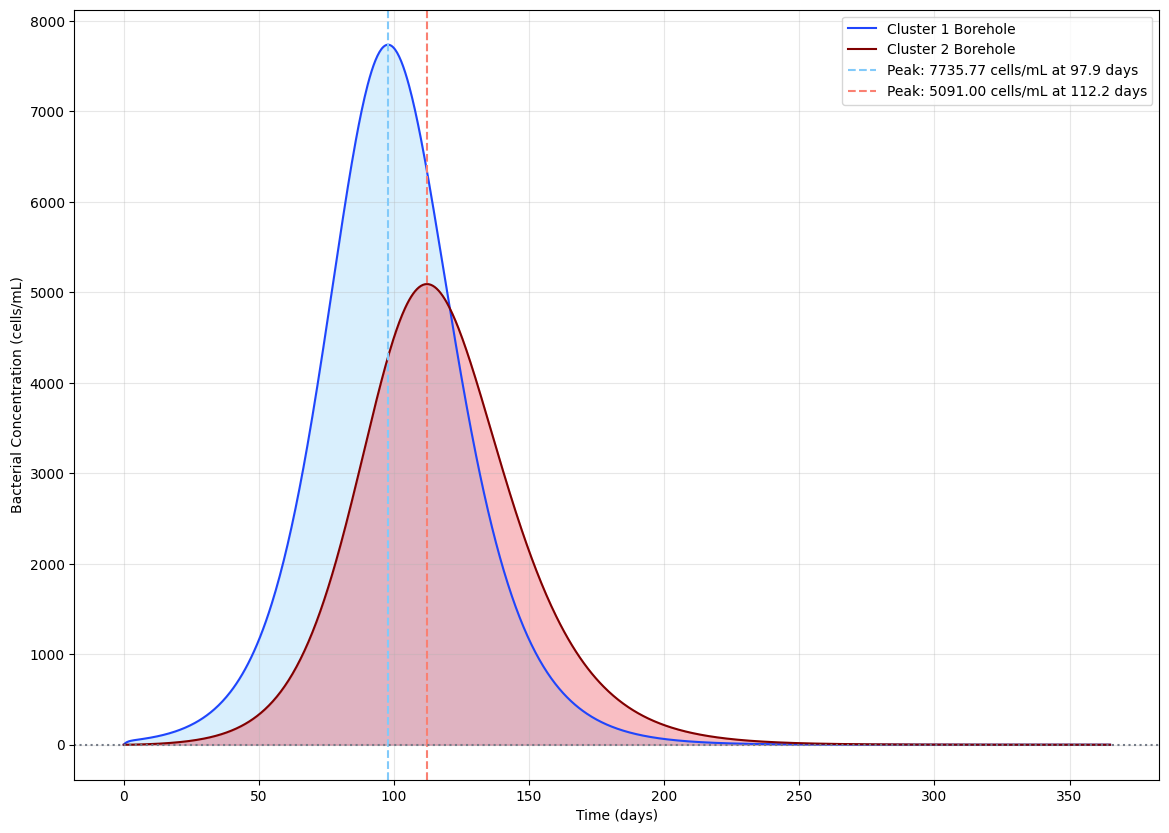

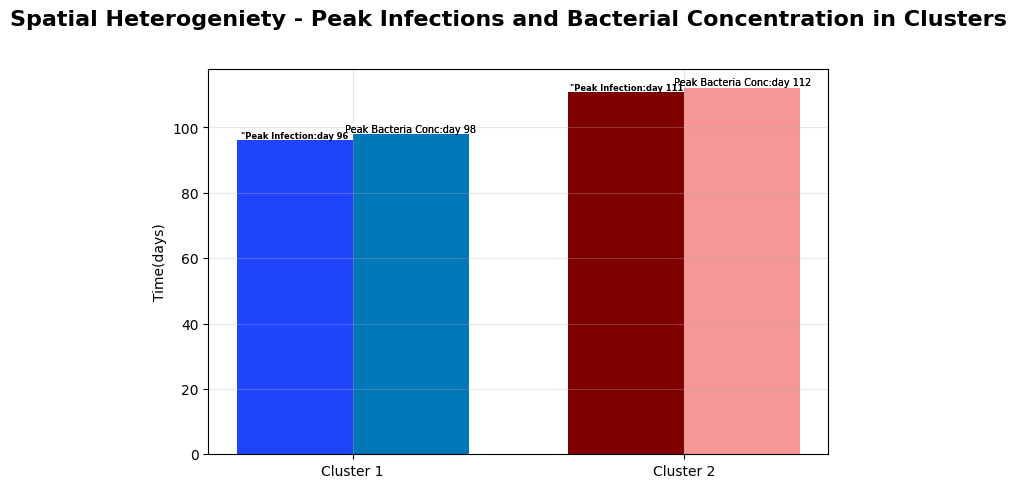

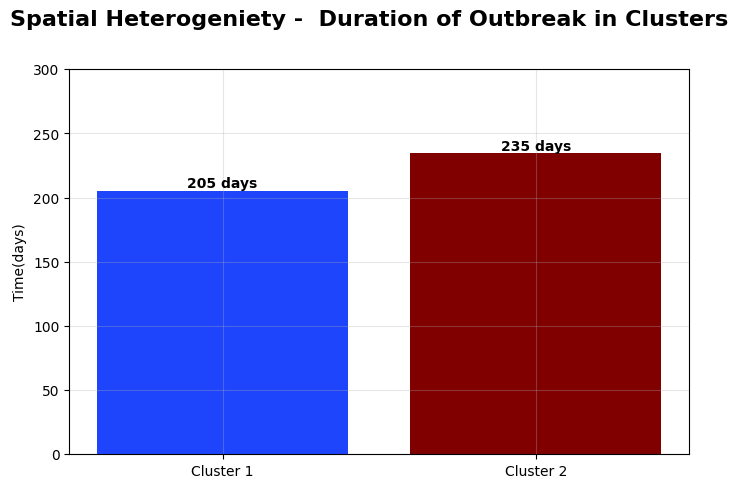

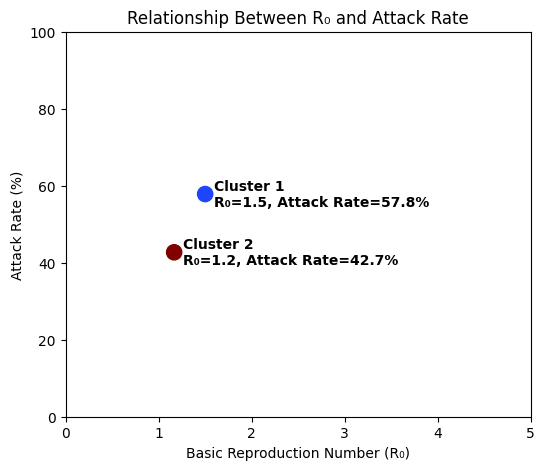

In [8]:
########Epidemic Curves: BASELINE MODEL (before interventions)
#combine curves
fig6, (ax) = plt.subplots(figsize=(14, 10))
fig6.suptitle("Epidemic Curve: Baseline Model (No Interventions)", fontsize=16, fontweight='bold', y=1.02)


ax.plot(t, I1_total, color = '#1F45FC', label = 'Cluster 1 Curve')
ax.plot(t,I2_total, color = '#800000', label = "Cluster 2 Curve")

ax.fill_between(t, I1_total, color='#82CAFA', alpha=0.3)
ax.fill_between(t, I2_total, color='#ED2939', alpha=0.3)

ax.axvline(x = peak1_time, linestyle = '--', color = '#757C88', label = f'Peak: {peak1:.0f} infected, ({100*peak1/H1:.1f}%) of population, {peak1_time:.1f} days')

ax.axvline(x = peak2_time, linestyle = '--', color = '#757C88', label = f'Peak: {peak2:.0f} infected, ({100*peak2/H2:.1f}%) of population, {peak2_time:.1f} days'  )

ax.grid(alpha=0.3)
ax.legend()

ax.set_title("Combined Epidemic Curve of Clusters", fontweight='bold')
ax.set_xlabel('Time(days)')
ax.set_ylabel('Number of Individuals')
plt.show()


###########Seperate cluster curves
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

#cluster1 plot
ax1.plot(t, I1_total, color = '#1F45FC', label = 'Cluster 1 Total Infected')
ax1.plot(t,Ia1, linestyle = '--', color = '#659EC7', label = f"Asymptomatic:{peakIa1:.0f}, ({100*peakIa1/peak1:.0f}% of infected)")
ax1.plot(t, Is1, linestyle = '--',  color = '#82CAFA', label = f"Symptomatic: {peakIs1:.0f}, ({100*peakIs1/peak1:.0f}% of infected)")

ax1.axvline(x = peak1_time, linestyle = '--', color = '#757C88', label = f'Peak: {peak1:.0f} infected, ({100*peak1/H1:.1f}%) of population, {peak1_time:.1f} days')
ax1.grid(alpha=0.3)
ax1.legend()

#cluster2 plot
ax2.plot(t, I2_total, color = '#800000', label = 'Cluster 2 Total Infected')
ax2.plot(t,Ia2, linestyle = '--', color = '#D30000', label = f"Asymptomatic: {peakIa2:.0f}, ({100*peakIa2/peak2:.0f}% of infected)")
ax2.plot(t, Is2, linestyle = '--',  color = '#ED2939', label = f"Symptomatic: {peakIs2:.0f}, ({100*peakIs2/peak2:.0f}% of infected)")

ax2.axvline(x = peak2_time, linestyle = '--', color = '#757C88', label = f'Peak: {peak2:.0f} infected, ({100*peak2/H2:.1f}%) of population, {peak2_time:.1f} days'  )
ax2.grid(alpha=0.3)
ax2.legend()

#titles
ax1.set_title(f'Cluster 1, Attack Rate {attack_rate1:.2f}% , Duration {cluster1_duration:.0f} days', fontweight='bold')
ax1.set_xlabel('Time(days)')
ax1.set_ylabel('Number of Individuals')
plt.tight_layout()

ax2.set_title(f'Cluster 2, Attack Rate {attack_rate2:.2f}% , Duration {cluster2_duration:.0f} days', fontweight='bold')
ax2.set_xlabel('Time(days)')
ax2.set_ylabel('Number of Individuals')
plt.tight_layout()
plt.show()


########Bacterial Concentration of Water Reservoir
fig2, ax = plt.subplots(figsize=(14, 10))


B1_plot = B1_baseline
B2_plot = B2_baseline

ax.plot(t, B1_plot, color='#1F45FC', label="Cluster 1 Borehole")
ax.plot(t, B2_plot, color='#800000', label="Cluster 2 Borehole")

ax.fill_between(t, B1_plot, color='#82CAFA', alpha=0.3)
ax.fill_between(t, B2_plot, color='#ED2939', alpha=0.3)

ax.axvline(x=peak_B1_time, linestyle='--', color='#82CAFA', label=f'Peak: {np.max(B1_plot):.2f} cells/mL at {peak_B1_time:.1f} days')
ax.axvline(x=peak_B2_time, linestyle='--', color='#FA8072', label=f'Peak: {np.max(B2_plot):.2f} cells/mL at {peak_B2_time:.1f} days')

ax.axhline(linestyle=':', color='#757C88')

ax.grid(alpha=0.3)
ax.legend()
ax.set_xlabel('Time (days)')
ax.set_ylabel('Bacterial Concentration (cells/mL)')
plt.show()


#######Spatial heterogeniety charts

#peak infection + concentration bar graph
labels = ['Cluster 1','Cluster 2']
attack_rates = [attack_rate1, attack_rate2]
peak_infect = [peak1_time, peak2_time]
peak_conc = [peak_B1_time, peak_B2_time]
R0 = [R0_1, R0_2]
duration = [cluster1_duration, cluster2_duration]

x=np.arange(len(labels))
width = 0.35
fig4, ax= plt.subplots(figsize=(8,5))
fig4.suptitle("Spatial Heterogeniety - Peak Infections and Bacterial Concentration in Clusters", fontsize=16, fontweight='bold', y=1.0)

bars2 = ax.bar(x-width/2, peak_infect, width, label='Peak Infections', color = ['#1F45FC', '#800000'])
bars22 = ax.bar(x+width/2, peak_conc,width, label = "Peak Bacterial Concentration", color = ['#0077B6', '#F69697'])

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Time(days)")

for bar in bars2:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2,
          height,
          f'"Peak Infection:day {height:.0f}',
          ha='center',
          va='bottom',
           fontweight='bold',
          fontsize = 6
           )
  for bar in bars22:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
          height,
          f'Peak Bacteria Conc:day {height:.0f}',
          ha='center',
          va='bottom',
           fontsize = 7
            )
ax.grid(alpha=0.3)


###########Outbreak duration
fig5, ax = plt.subplots(figsize=(8,5))
fig5.suptitle("Spatial Heterogeniety -  Duration of Outbreak in Clusters", fontsize=16, fontweight='bold', y=1.0)
bars4 = ax.bar(labels, duration, color = ['#1F45FC', '#800000'])
ax.set_ylim(0, 300)
ax.set_ylabel("Time(days)")

for bar in bars4:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2,
          height,
          f'{height:.0f} days',
          ha='center',
          va='bottom',
          fontweight='bold'
          )
ax.grid(alpha=0.3)

############Scatter plot - relationship between R0 and Attack Rate
fig7, ax = plt.subplots(figsize=(6,5))
ax.scatter(R0, attack_rates, s=120, color=['#1F45FC','#800000'])

for i, label in enumerate(labels):
    ax.text(
        R0[i] + 0.1,          # move slightly to the right
        attack_rates[i],
        f'{label}\nR₀={R0[i]:.1f}, Attack Rate={attack_rates[i]:.1f}%',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel("Basic Reproduction Number (R₀)")
ax.set_ylabel("Attack Rate (%)")
ax.set_title("Relationship Between R₀ and Attack Rate")
ax.set_ylim(0, 100)
ax.set_xlim(0, 5)

plt.show()



Sensitivity Analysis

In [9]:
#parameter values
params_baseline = {
    'H1':H1,
    'H2': H2,
    'a1': a1,
    'a2': a2,
    'sigma': sigma,
    'r': r,
    'K': K,
    'ea': ea,
    'es': es,
    'mb': mb,
    'm': m
}
#initial conditions
def run_model(params):
    S1_0 = params['H1']-1; Ia1_0 = 0; Is1_0 = 1; R1_0 = 0; B1_0 = 0
    S2_0 = params['H2'];   Ia2_0 = 0; Is2_0 = 0; R2_0 = 0; B2_0 = 0
    y0 = [S1_0, Ia1_0, Is1_0, R1_0, B1_0,
          S2_0, Ia2_0, Is2_0, R2_0, B2_0]
    #define ode system
    def ode(y,t):
      S1, Ia1, Is1, R1, B1, S2, Ia2, Is2, R2, B2 = y
      #force of infection
      lam1 = B1/(params['K'] + B1) if B1>0 else 0
      lam2 = (B2/(params['K'] + B2) if B2>0 else 0) + (params['m'] * lam1)
      #cluster 1
      dS1 = -params['a1'] * lam1 *S1
      dIa1 = (1-params['sigma']) * params['a1'] * lam1 * S1 - params['r'] * Ia1
      dIs1 = params['sigma'] * params['a1'] * lam1 * S1 -params['r'] * Is1
      dR1 = params['r'] * (Ia1 +Is1)
      dB1 = -params['mb']*B1 + params['ea']*Ia1 + params['es']*Is1
      #cluster2
      dS2 = -params['a2'] * lam2 *S2
      dIa2 = (1-params['sigma']) * params['a2'] * lam2 * S2 - params['r'] * Ia2
      dIs2 = params['sigma'] * params['a2'] * lam2 * S2 -params['r'] * Is2
      dR2 = params['r'] * (Ia2+Is2)
      dB2 = -params['mb']*B2 + params['ea']*Ia2 + params['es']*Is2

      return [dS1, dIa1, dIs1, dR1, dB1, dS2, dIa2, dIs2, dR2, dB2]

    t = np.linspace(0,365,1000)
    sol = odeint(ode, y0, t)

    I1 = sol[-1,3]
    I2 = sol[-1,8]
    return (I1 + I2)

delta = 0.05
baseline = run_model(params_baseline)
results = {}

for param in ['a1', 'a2' ,'sigma', 'r', 'K', 'ea', 'es', 'mb', 'm']:
  high = params_baseline.copy()
  high[param] = high[param] * (1+delta)

  low = params_baseline.copy()
  low[param] = low[param] * (1-delta)

  # Run model
  Y_high = run_model(high)
  Y_low  = run_model(low)

  # Sensitivity calculation
  F = ((Y_high - Y_low) / baseline) / (2 * delta)

  results[param] = round(F, 3)

print("Sensitivity Results:\n")

for param, value in sorted(results.items(), key=lambda x: abs(x[1]), reverse=True):
    print(param, ":", value)

Sensitivity Results:

r : -2.056
mb : -2.051
K : -2.049
es : 1.902
sigma : 1.849
a1 : 1.125
a2 : 0.939
ea : 0.154
m : 0.102


In [10]:
peak_B1_conc = B1[peak_B1] #peak conc
peak_B2 = np.argmax(B1)
peak_B2_conc = B2[peak_B2] #peak conc
print(peak_B1_conc)

7735.767992979848


Interventions

In [11]:
#chlorination
def cholera_chlorination(y, t, cl):
  #state variables
  S1, Ia1, Is1, R1, B1, S2,Ia2, Is2, R2, B2 = y
  #force of infection
  lam1 = lambda_cluster1(B1, B2, Ia1, Ia2, Is1, Is2)
  lam2 = lambda_cluster2(B1, B2, Ia1, Ia2, Is1, Is2)
  #cluster1
  dS1= -a1 * lam1 * S1
  dIa1 = (1-sigma) * a1 * lam1 * S1 - r * Ia1
  dIs1 = sigma * a1 *  lam1 * S1 - r * Is1
  dR1 = r * (Ia1 + Is1)
  dB1 = -mb*B1 + ea*Ia1 + es*Is1 - cl*B1  #treat cluster1 water reservoir
  #cluster 2 equations
  dS2= -a2 * lam2 * S2
  dIa2 = (1-sigma) * a2 * lam2 * S2 - r * Ia2
  dIs2 = sigma * a2 *  lam2 * S2 - r * Is2
  dR2 = r * (Ia2 + Is2)
  dB2 = -mb*B2 + ea*Ia2 + es*Is2 - cl*B2  #treat cluster2 water reservoir
  #return all values
  return[dS1, dIa1, dIs1, dR1, dB1, dS2, dIa2, dIs2, dR2, dB2]

chlorination_results = {}
for label, cl in chlorine_levels.items():
  #solve ode
  sol = odeint(cholera_chlorination, y0, t, args=(cl,))
  S1 = sol[:,0]
  Ia1 = sol[:,1]
  Is1 = sol[:,2]
  R1 = sol[:,3]
  B1 = sol[:,4]

  S2 = sol[:,5]
  Ia2 = sol[:,6]
  Is2 = sol[:,7]
  R2 = sol[:,8]
  B2 = sol[:,9]

  #total infected
  I1 = Ia1  + Is1
  I2 = Ia2 + Is2
  #final susceptible
  S1_end = S1[-1]
  S2_end = S2[-1]
  #peak bacterial concentration
  peak_B1 = np.argmax(B1)
  peak_B1_conc = B1[peak_B1] #peak conc
  peak_B2 = np.argmax(B2)
  peak_B2_conc = B2[peak_B2] #peak conc
  #attack rates
  AR1 = (H1 - S1_end)/H1*100
  AR2 = (H2 - S2_end)/H2*100
  #R_0
  R0_1 = (a1 * H1 * weighted_shedding) / (r * (mb + cl) * K)
  R0_2 = (a2 * H2 * weighted_shedding) / (r * (mb + cl) * K)

  chlorination_results[label] = {
      'I1':I1,
      'I2':I2,
      'Peak B1':peak_B1_conc,
      'Peak B2':peak_B2_conc,
      'AR1': AR1,
      'AR2': AR2,
      'R0_1': R0_1,
      'R0_2': R0_2
  }


print(f"{'Chlorination':<20} {'AR1 (%)':>10} {'AR2 (%)':>8} {'Peak B1':>9} {'Peak B2':>9} {'R0_1':>9} {'R0_2':>9}")
print("-" * 80)
for label, res in chlorination_results.items():
  print(f"{label:<20}"
    f"{res['AR1']:>10.2f}"
    f"{res['AR2']:>10.2f}"
    f"{res['Peak B1']:>10.2f}"
    f"{res['Peak B2']:>10.2f}"
    f"{res['R0_1']:>10.2f}"
    f"{res['R0_2']:>10.2f}")

######################################################################################
#latrines
def cholera_latrines(y, t, lc):
  #state variables
  S1, Ia1, Is1, R1, B1, S2,Ia2, Is2, R2, B2 = y
  #force of infection
  lam1 = lambda_cluster1(B1, B2, Ia1, Ia2, Is1, Is2)
  lam2 = lambda_cluster2(B1, B2, Ia1, Ia2, Is1, Is2)
  #cluster1
  dS1= -a1 * lam1 * S1
  dIa1 = (1-sigma) * a1 * lam1 * S1 - r * Ia1
  dIs1 = sigma * a1 *  lam1 * S1 - r * Is1
  dR1 = r * (Ia1 + Is1)
  dB1 = -mb*B1 + (ea*(1-lc))*Ia1 + (es*(1-lc))*Is1  #reduced shedding
  #cluster 2 equations
  dS2= -a2 * lam2 * S2
  dIa2 = (1-sigma) * a2 * lam2 * S2 - r * Ia2
  dIs2 = sigma * a2 *  lam2 * S2 - r * Is2
  dR2 = r * (Ia2 + Is2)
  dB2 = -mb*B2 + (ea*(1-lc))*Ia2 + (es*(1-lc))*Is2  #reduced shedding
  #return all values
  return[dS1, dIa1, dIs1, dR1, dB1, dS2, dIa2, dIs2, dR2, dB2]

latrine_results = {}
for label, lc in latrine_levels.items():
  #solve ode
  sol = odeint(cholera_latrines, y0, t, args=(lc,))
  S1 = sol[:,0]
  Ia1 = sol[:,1]
  Is1 = sol[:,2]
  R1 = sol[:,3]
  B1 = sol[:,4]

  S2 = sol[:,5]
  Ia2 = sol[:,6]
  Is2 = sol[:,7]
  R2 = sol[:,8]
  B2 = sol[:,9]

  #total infected
  I1 = Ia1  + Is1
  I2 = Ia2 + Is2
  #final susceptible
  S1_end = S1[-1]
  S2_end = S2[-1]
  #peak concentration
  peak_B1 = np.argmax(B1)
  peak_B1_conc = B1[peak_B1] #peak conc
  peak_B2 = np.argmax(B2)
  peak_B2_conc = B2[peak_B2] #peak conc
  #attack rates
  AR1 = (H1 - S1_end)/H1*100
  AR2 = (H2 - S2_end)/H2*100
  #R_0
  R0_1 = (a1 * H1 * (weighted_shedding * (1-lc))) / (r * (mb) * K)
  R0_2 = (a2 * H2 * (weighted_shedding * (1-lc))) / (r * (mb) * K)


  latrine_results[label] = {
      'I1':I1,
      'I2':I2,
      'Peak B1':peak_B1_conc,
      'Peak B2':peak_B2_conc,
      'AR1': AR1,
      'AR2': AR2,
      'R0_1': R0_1,
      'R0_2': R0_2
  }

print("-" * 80)
print(f"{'Latrine Coverage':<20} {'AR1 (%)':>10} {'AR2 (%)':>10} {'Peak B1':>8} {'Peak B2':>9} {'R0_1':>9} {'R0_2':>9}")
print("-" * 80)
for label, res in latrine_results.items():
  print(f"{label:<20}"
    f"{res['AR1']:>10.2f}"
    f"{res['AR2']:>10.2f}"
    f"{res['Peak B1']:>10.2f}"
    f"{res['Peak B2']:>10.2f}"
    f"{res['R0_1']:>10.2f}"
    f"{res['R0_2']:>10.2f}")

######################################################################################
#borehole suspension
def cholera_suspension(y, t, m_v):
  #state variables
  S1, Ia1, Is1, R1, B1, S2,Ia2, Is2, R2, B2 = y
  #force of infection
  lam1 = ((B1/(K+B1))if B1>0 else 0 )
  lam2 = ((B2/(K+B2))if B2>0 else 0 ) + (m_v * (B1/(K+B1) if B1>0 else 0 ))
  #cluster1
  dS1= -a1 * lam1 * S1
  dIa1 = (1-sigma) * a1 * lam1 * S1 - r * Ia1
  dIs1 = sigma * a1 *  lam1 * S1 - r * Is1
  dR1 = r * (Ia1 + Is1)
  dB1 = -mb*B1 + ea*Ia1 + es*Is1
  #cluster 2 equations
  dS2= -a2 * lam2 * S2
  dIa2 = (1-sigma) * a2 * lam2 * S2 - r * Ia2
  dIs2 = sigma * a2 *  lam2 * S2 - r * Is2
  dR2 = r * (Ia2 + Is2)
  dB2 = -mb*B2 + ea*Ia2 + es*Is2
  #return all values
  return[dS1, dIa1, dIs1, dR1, dB1, dS2, dIa2, dIs2, dR2, dB2]

suspension_results = {}
for label, m_v in suspension_levels.items():
  #solve ode
  sol = odeint(cholera_suspension, y0, t, args=(m_v,))
  S1 = sol[:,0]
  Ia1 = sol[:,1]
  Is1 = sol[:,2]
  R1 = sol[:,3]
  B1 = sol[:,4]

  S2 = sol[:,5]
  Ia2 = sol[:,6]
  Is2 = sol[:,7]
  R2 = sol[:,8]
  B2 = sol[:,9]

  #total infected
  I1 = Ia1  + Is1
  I2 = Ia2 + Is2
  #final susceptible
  S1_end = S1[-1]
  S2_end = S2[-1]
  #peak concentration
  peak_B1 = np.argmax(B1)
  peak_B1_conc = B1[peak_B1] #peak conc
  peak_B2 = np.argmax(B2)
  peak_B2_conc = B2[peak_B2] #peak conc
  #attack rates
  AR1 = (H1 - S1_end)/H1*100
  AR2 = (H2 - S2_end)/H2*100
  #R_0
  R0_1 = (a1 * H1 * weighted_shedding) / (r * (mb) * K)
  R0_2 = (a2 * H2 * weighted_shedding) / (r * (mb) * K)



  suspension_results[label] = {
      'I1':I1,
      'I2':I2,
      'Peak B1':peak_B1_conc,
      'Peak B2':peak_B2_conc,
      'AR1': AR1,
      'AR2': AR2,
      'R0_1': R0_1,
      'R0_2': R0_2
  }

print("-" * 80)
print(f"{'Suspension':<20} {'AR1 (%)':>10} {'AR2 (%)':>10} {'Peak B1':>8} {'Peak B2':>9} {'R0_1':>9} {'R0_2':>9}")
print("-" * 80)
for label, res in suspension_results.items():
  print(f"{label:<20}"
    f"{res['AR1']:>10.2f}"
    f"{res['AR2']:>10.2f}"
    f"{res['Peak B1']:>10.2f}"
    f"{res['Peak B2']:>10.2f}"
    f"{res['R0_1']:>10.2f}"
    f"{res['R0_2']:>10.2f}")

######################################################################################
#vaccination
vax_results = {}
for label, v in vax_levels.items():
  #initial compartment valuess
  S1_v0 = (H1-1) * (1-v)
  S2_v0 = H2 * (1-v)
  R1_v0 = (H1-1) * v
  R2_v0 = H2 * v
  y0v = [S1_v0, 0, 1, R1_v0, 0,
         S2_v0, 0, 0, R2_v0, 0]
  #solve ode
  sol = odeint(cholera2_cluster, y0v, t)
  S1 = sol[:,0]
  Ia1 = sol[:,1]
  Is1 = sol[:,2]
  R1 = sol[:,3]
  B1 = sol[:,4]

  S2 = sol[:,5]
  Ia2 = sol[:,6]
  Is2 = sol[:,7]
  R2 = sol[:,8]
  B2 = sol[:,9]

  #total infected
  I1 = Ia1  + Is1
  I2 = Ia2 + Is2
  #final susceptible
  S1_end = S1[-1]
  S2_end = S2[-1]
  #peak concentration
  peak_B1 = np.argmax(B1)
  peak_B1_conc = B1[peak_B1] #peak conc
  peak_B2 = np.argmax(B2)
  peak_B2_conc = B2[peak_B2] #peak conc
  #attack rates
  AR1 = (S1_v0 - S1_end)/S1_v0*100
  AR2 = (S2_v0 - S2_end)/S2_v0*100
  #R_0
  R0_1 = ((a1 * H1 * weighted_shedding) / (r * (mb) * K) * (1-v))
  R0_2 = ((a2 * H2 * weighted_shedding) / (r * (mb) * K) * (1-v))



  vax_results[label] = {
      'I1':I1,
      'I2':I2,
      'Peak B1':peak_B1_conc,
      'Peak B2':peak_B2_conc,
      'AR1': AR1,
      'AR2': AR2,
      'R0_1': R0_1,
      'R0_2': R0_2
  }

print("-" * 80)
print(f"{'Vaccination':<20} {'AR1 (%)':>10} {'AR2 (%)':>10} {'Peak B1':>8} {'Peak B2':>9} {'R0_1':>9} {'R0_2':>9}")
print("-" * 80)
for label, res in vax_results.items():
  print(f"{label:<20}"
    f"{res['AR1']:>10.2f}"
    f"{res['AR2']:>10.2f}"
    f"{res['Peak B1']:>10.2f}"
    f"{res['Peak B2']:>10.2f}"
    f"{res['R0_1']:>10.2f}"
    f"{res['R0_2']:>10.2f}")


Chlorination            AR1 (%)  AR2 (%)   Peak B1   Peak B2      R0_1      R0_2
--------------------------------------------------------------------------------
Baseline (cl = 0 )       57.83     42.71   7735.77   5091.00      1.50      1.17
Low (cl = 0.1)           40.73     24.58   2967.10   1637.62      1.29      1.00
Moderate (cl = 0.2 )     20.54      8.89    672.53    290.70      1.12      0.87
High (cl = 0.5)           0.18      0.03     26.54      2.32      0.82      0.64
--------------------------------------------------------------------------------
Latrine Coverage        AR1 (%)    AR2 (%)  Peak B1   Peak B2      R0_1      R0_2
--------------------------------------------------------------------------------
Baseline (lc = 0 )       57.83     42.71   7735.77   5091.00      1.50      1.17
Low (lc = 0.1)           46.69     30.47   4124.87   2431.86      1.35      1.05
Moderate (lc = 0.2 )     31.24     16.29   1492.88    736.64      1.20      0.93
High (lc = 0.5)           0

Intervention Visualisation part1 graphs



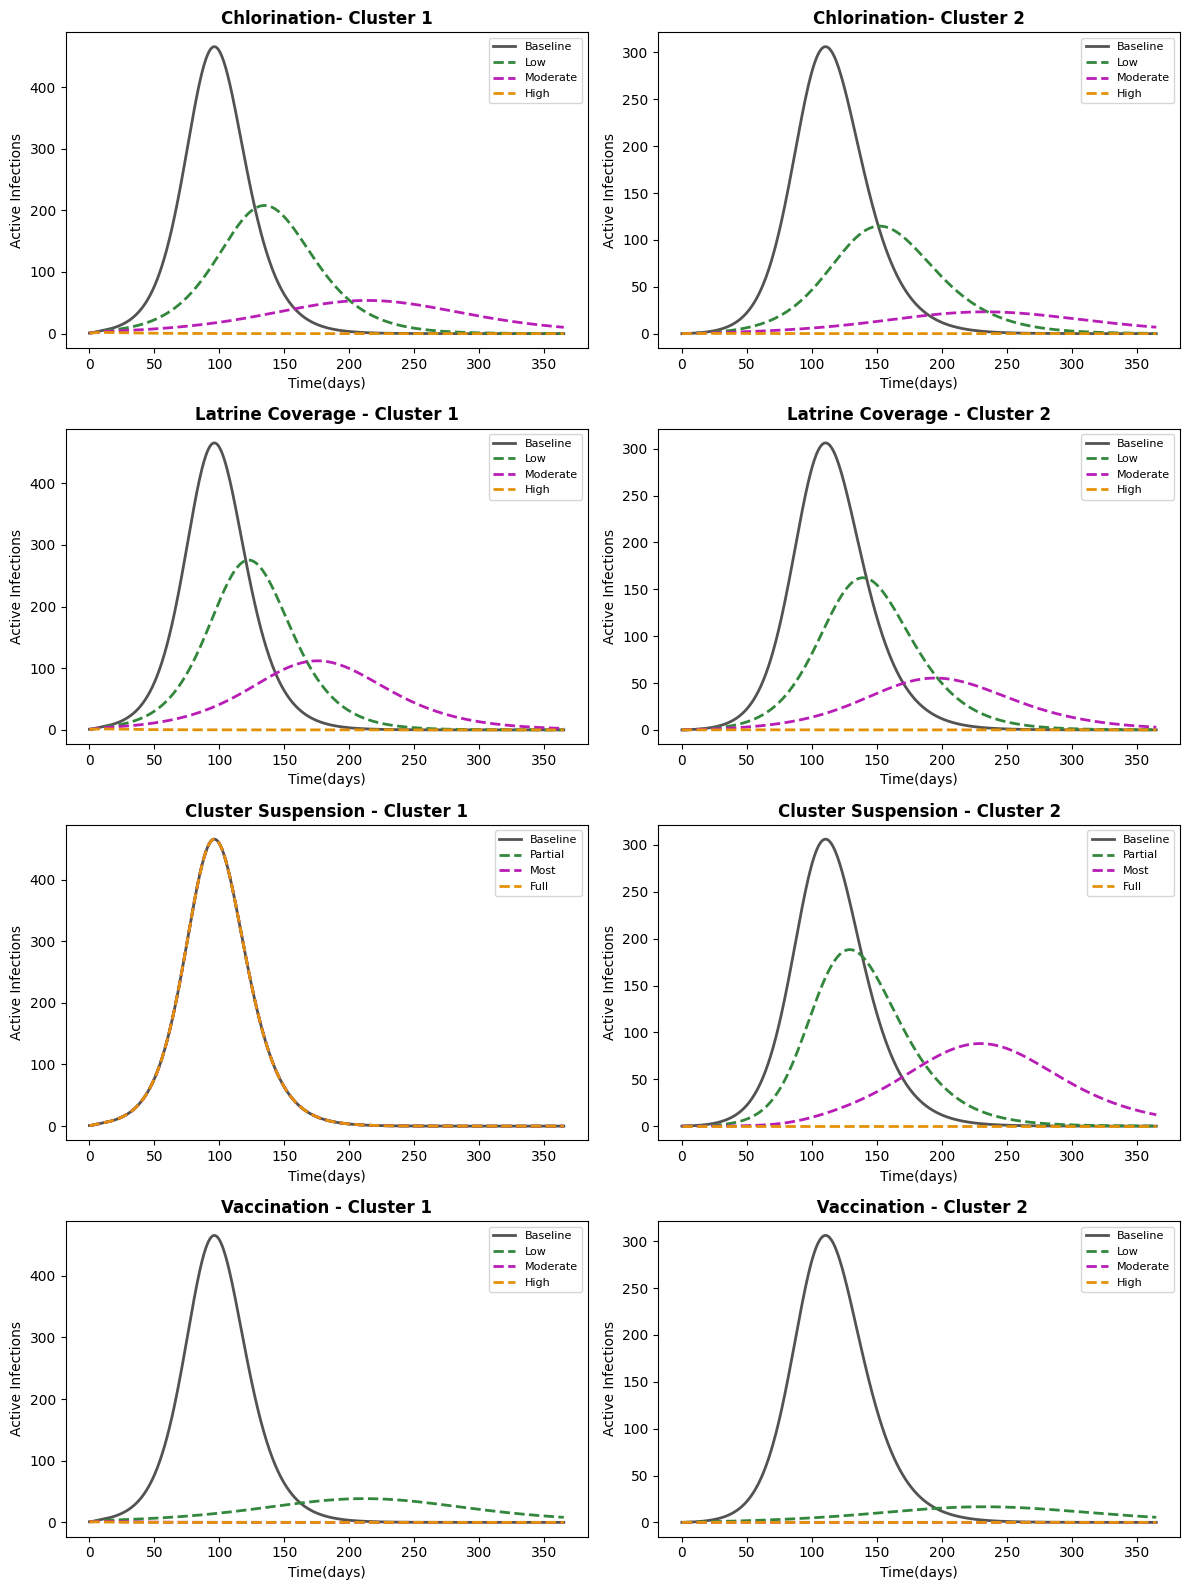

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

#chlorination
c_baseline = list(chlorination_results.values())[0]
c_low = list(chlorination_results.values())[1]
c_moderate = list(chlorination_results.values())[2]
c_high = list(chlorination_results.values())[3]

axes[0,0].plot(t, c_baseline['I1'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[0,0].plot(t, c_low['I1'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[0,0].plot(t, c_moderate['I1'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[0,0].plot(t, c_high['I1'],  color='#E39207', lw=2, ls='--',  label='High')
axes[0,0].set_title('Chlorination- Cluster 1', fontweight='bold')
axes[0,0].set_xlabel('Time(days)')
axes[0,0].set_ylabel('Active Infections')
axes[0,0].legend(fontsize=8)

axes[0,1].plot(t, c_baseline['I2'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[0,1].plot(t, c_low['I2'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[0,1].plot(t, c_moderate['I2'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[0,1].plot(t, c_high['I2'],  color='#E39207', lw=2, ls='--',  label='High')
axes[0,1].set_title('Chlorination- Cluster 2', fontweight='bold')
axes[0,1].set_xlabel('Time(days)')
axes[0,1].set_ylabel('Active Infections')
axes[0,1].legend(fontsize=8)


#latrine coverage
lc_baseline = list(latrine_results.values())[0]
lc_low = list(latrine_results.values())[1]
lc_moderate = list(latrine_results.values())[2]
lc_high = list(latrine_results.values())[3]

axes[1,0].plot(t, lc_baseline['I1'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[1,0].plot(t, lc_low['I1'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[1,0].plot(t, lc_moderate['I1'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[1,0].plot(t, lc_high['I1'],  color='#E39207', lw=2, ls='--',  label='High')
axes[1,0].set_title('Latrine Coverage - Cluster 1', fontweight='bold')
axes[1,0].set_xlabel('Time(days)')
axes[1,0].set_ylabel('Active Infections')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(t, lc_baseline['I2'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[1,1].plot(t, lc_low['I2'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[1,1].plot(t, lc_moderate['I2'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[1,1].plot(t, lc_high['I2'],  color='#E39207', lw=2, ls='--',  label='High')
axes[1,1].set_title('Latrine Coverage - Cluster 2', fontweight='bold')
axes[1,1].set_xlabel('Time(days)')
axes[1,1].set_ylabel('Active Infections')
axes[1,1].legend(fontsize=8)


#cluster suspension
s_baseline = list(suspension_results.values())[0]
s_partial = list(suspension_results.values())[1]
s_most = list(suspension_results.values())[2]
s_full = list(suspension_results.values())[3]

axes[2,0].plot(t, s_baseline['I1'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[2,0].plot(t, s_partial['I1'],  color='#33873D', lw=2, ls='--',  label='Partial')
axes[2,0].plot(t, s_most['I1'],  color='#B81DB6', lw=2, ls='--',  label='Most')
axes[2,0].plot(t, s_full['I1'],  color='#E39207', lw=2, ls='--',  label='Full')
axes[2,0].set_title('Cluster Suspension - Cluster 1', fontweight='bold')
axes[2,0].set_xlabel('Time(days)')
axes[2,0].set_ylabel('Active Infections')
axes[2,0].legend(fontsize=8)

axes[2,1].plot(t, s_baseline['I2'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[2,1].plot(t, s_partial['I2'],  color='#33873D', lw=2, ls='--',  label='Partial')
axes[2,1].plot(t, s_most['I2'],  color='#B81DB6', lw=2, ls='--',  label='Most')
axes[2,1].plot(t, s_full['I2'],  color='#E39207', lw=2, ls='--',  label='Full')
axes[2,1].set_title('Cluster Suspension - Cluster 2', fontweight='bold')
axes[2,1].set_xlabel('Time(days)')
axes[2,1].set_ylabel('Active Infections')
axes[2,1].legend(fontsize=8)


#vaccination
v_baseline = list(vax_results.values())[0]
v_low = list(vax_results.values())[1]
v_moderate = list(vax_results.values())[2]
v_high = list(vax_results.values())[3]


axes[3,0].plot(t, v_baseline['I1'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[3,0].plot(t, v_low['I1'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[3,0].plot(t, v_moderate['I1'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[3,0].plot(t, v_high['I1'],  color='#E39207', lw=2, ls='--',  label='High')
axes[3,0].set_title('Vaccination - Cluster 1', fontweight='bold')
axes[3,0].set_xlabel('Time(days)')
axes[3,0].set_ylabel('Active Infections')
axes[3,0].legend(fontsize=8)

axes[3,1].plot(t, v_baseline['I2'],  color='#545351', lw=2, ls='-',  label='Baseline')
axes[3,1].plot(t, v_low['I2'],  color='#33873D', lw=2, ls='--',  label='Low')
axes[3,1].plot(t, v_moderate['I2'],  color='#B81DB6', lw=2, ls='--',  label='Moderate')
axes[3,1].plot(t, v_high['I2'],  color='#E39207', lw=2, ls='--',  label='High')
axes[3,1].set_title(' Vaccination - Cluster 2', fontweight='bold')
axes[3,1].set_xlabel('Time(days)')
axes[3,1].set_ylabel('Active Infections')
axes[3,1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Intervention visualisation part 2 attack rate

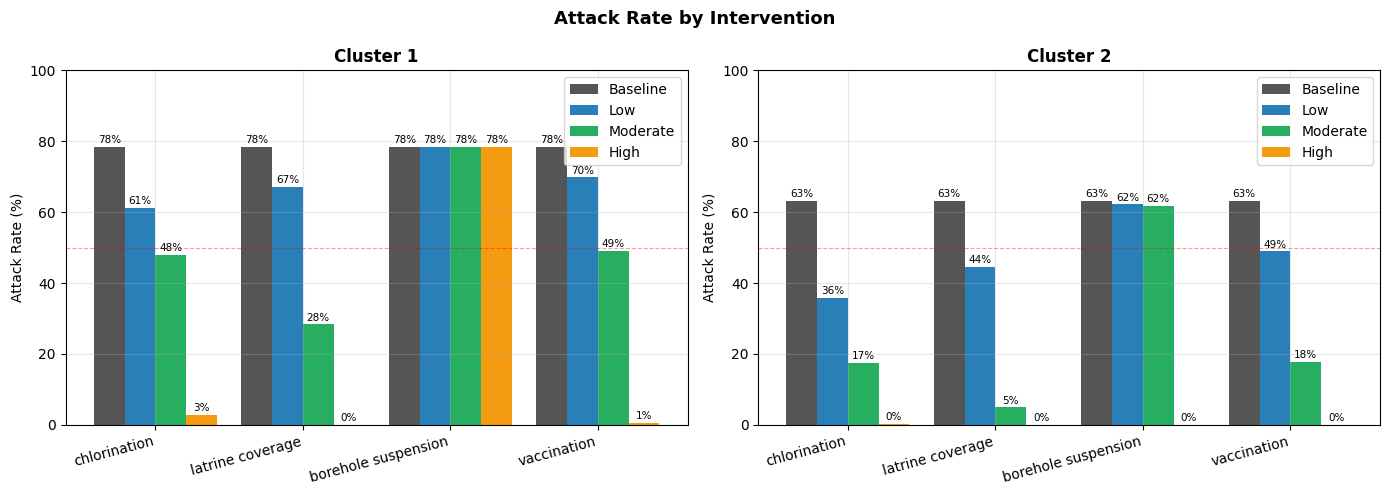

In [13]:
labels = ['chlorination', 'latrine coverage', 'borehole suspension', 'vaccination']
#cluster1
AR1_baseline = [78.3, 78.3, 78.3, 78.3]
AR1_low = [61.3, 67.1, 78.3, 69.8]
AR1_moderate = [48.0, 28.3, 78.3, 49.0]
AR1_high = [2.9, 0.0, 78.3, 0.6]
#cluster2
AR2_baseline = [63.1, 63.1, 63.1, 63.1]
AR2_low = [35.7, 44.5, 62.2,48.9]
AR2_moderate = [17.4, 4.9, 61.8,17.8]
AR2_high = [0.3, 0.0, 0.0, 0.0]

x = np.arange(len(labels)) *1.2
width = 0.25


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attack Rate by Intervention', fontsize=13, fontweight='bold')

#cluster1
b1 = ax1.bar(x - 1.5*width, AR1_baseline, width, label='Baseline',color='#555555')
b2 = ax1.bar(x - 0.5*width, AR1_low, width, label='Low',color='#2980b9')
b3 = ax1.bar(x + 0.5*width, AR1_moderate, width, label='Moderate',color='#27ae60')
b4 = ax1.bar(x + 1.5*width, AR1_high, width, label='High',color='#f39c12')
#cluster2
b5 = ax2.bar(x - 1.5*width, AR2_baseline, width, label='Baseline', color='#555555')
b6 = ax2.bar(x - 0.5*width, AR2_low, width, label='Low',color='#2980b9')
b7 = ax2.bar(x + 0.5*width, AR2_moderate, width, label='Moderate',color='#27ae60')
b8 = ax2.bar(x + 1.5*width, AR2_high, width, label='High',color='#f39c12')

for ax, title in [(ax1, 'Cluster 1'), (ax2, 'Cluster 2')]:
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('Attack Rate (%)')
    ax.set_ylim(0, 100)
    ax.axhline(50, color='red', lw=0.8, ls='--', alpha=0.4)
    ax.legend()
    ax.grid(alpha=0.3)


for bar in [b1, b2, b3, b4, b5, b6, b7, b8]:
    for rect in bar:
        height = rect.get_height()
        rect.axes.text(rect.get_x() + rect.get_width()/2,
        height + 0.5, f'{height:.0f}%',
        ha='center',
        va='bottom',
        fontsize=7.5)


plt.tight_layout()
plt.show()

Intervention visualisation part3 R0

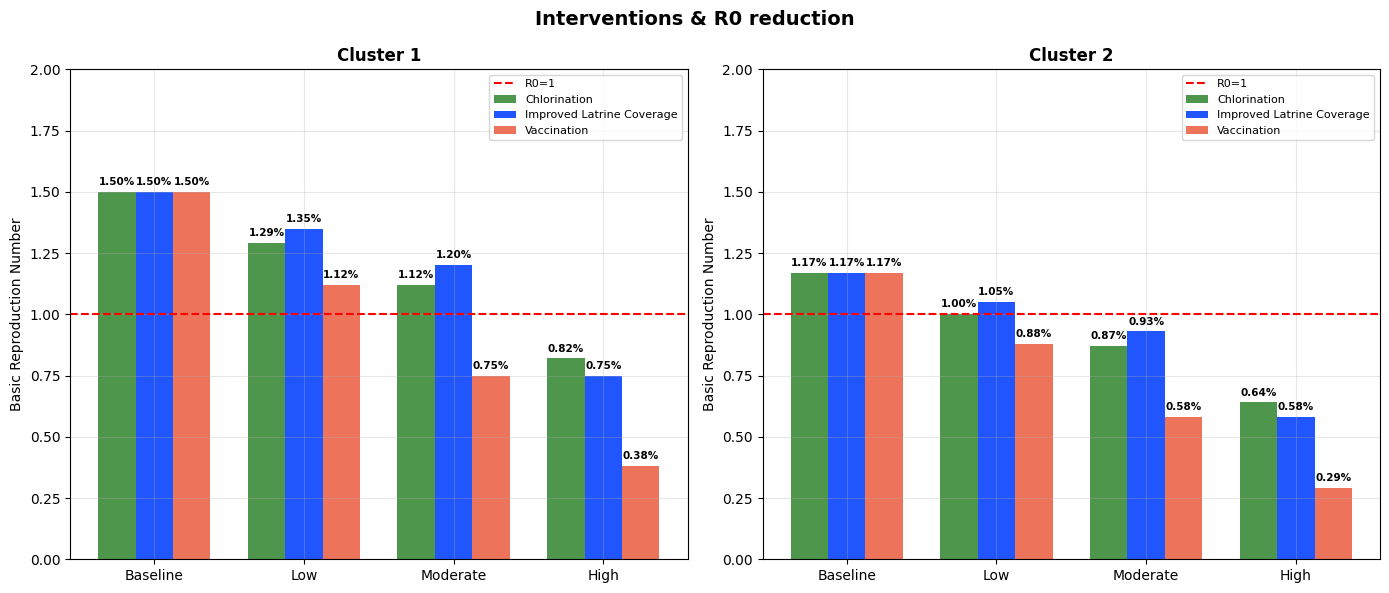

In [14]:
labels_r = ['Baseline', 'Low', 'Moderate', 'High']
#cluster1
chlorination1 = [1.50, 1.29, 1.12, 0.82]
latrines1 = [1.50, 1.35, 1.20, 0.75]
vaccination1 = [1.50, 1.12, 0.75, 0.38]
#cluster2
chlorination2 = [1.17,1.00, 0.87, 0.64]
latrines2 = [1.17, 1.05, 0.93, 0.58]
vaccination2 = [1.17, 0.88, 0.58, 0.29]

x = np.arange(len(labels_r))
y=3.0
width = 0.25

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Interventions & R0 reduction', fontsize=14, fontweight='bold')

#cluster1
bar_c1 = ax1.bar(x-width, chlorination1,width,label='Chlorination', color='#4E964B')
bar_l1 = ax1.bar(x, latrines1,width,label='Improved Latrine Coverage', color='#2156FF')
bar_v1 = ax1.bar(x+width, vaccination1,width,label='Vaccination', color='#ED745A')
#cluster2
bar_c2 = ax2.bar(x-width, chlorination2,width,label='Chlorination', color='#4E964B')
bar_l2 = ax2.bar(x, latrines2,width,label='Improved Latrine Coverage', color='#2156FF')
bar_v2 = ax2.bar(x+width, vaccination2,width,label='Vaccination', color='#ED745A')

ax1.axhline(y=1, color='red',lw=1.5,ls='--',label='R0=1')
ax2.axhline(y=1, color='red',lw=1.5,ls='--',label='R0=1')

for bars in [bar_c1, bar_l1, bar_v1, bar_c2, bar_l2, bar_v2]:
    for bar in bars:
        height = bar.get_height()
        bar.axes.text(bar.get_x() + bar.get_width()/2,
        height + 0.02, f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold')


ax1.set_title('Cluster 1', fontweight='bold')
ax2.set_title('Cluster 2', fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels_r)
    ax.set_ylabel('Basic Reproduction Number')
    ax.set_ylim(0, 2)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Sensitivity Analysis